# ensemble MSLP anomaly composite for a list of yyyymmdd dates

give a list of dates, and it returns the 12-member ensemble mean MSLP anomaly composited over those days, plus per member fields and figs. 

# settings
the thing you input is `DATES`  
the area the plot covers can be modified . 

In [94]:
import yaml

# yml file
YML = ('/home/users/david.sexton/DSexton/projects/ukci_tools/hackathon2025/'
       'saved_plots/matched_single_tasmax_True_28_3_3_South_East_England_5_5_20260902_161858.yml')

# dict to match ensemble keys
MEMBER_TO_ENSEMBLE = {
    '01': '0000',
    '04': '1113',
    '05': '1554',
    '06': '1649',
    '07': '1843',
    '08': '1935',
    '09': '2123',
    '10': '2242',
    '11': '2305',
    '12': '2335',
    '13': '2491',
    '15': '2868',
}

# only keep yml dates whose month (the 'mm' in yyyymmdd) is in this set.
# set to None to keep every month. e.g. ('07', '08', '09') for Jul-Sep.
SELECT_MONTHS = None

# only keep yml dates whose year (the 'yyyy' in yyyymmdd) is in this inclusive
# range. set to None to keep every year. e.g. (1980, 2010).
SELECT_YEARS = (1980, 2010)

# shift each selected date forward by this many days, so the composite is built
# on the day LAG_DAYS after the yml start date.
LAG_DAYS = 10


def _shift_label_360(label, lag):
    """Add `lag` days to a 'yyyymmdd' label on a 360-day (30-day month) calendar."""
    y, m, d = int(label[:4]), int(label[4:6]), int(label[6:8])
    total = y * 360 + (m - 1) * 30 + (d - 1) + lag
    y2, rem = divmod(total, 360)
    m2, d2 = divmod(rem, 30)
    return f"{y2:04d}{m2 + 1:02d}{d2 + 1:02d}"


with open(YML) as fh:
    _doc = yaml.safe_load(fh)

DATES = {}
for label, days in _doc['members'].items():
    ens = MEMBER_TO_ENSEMBLE.get(str(label))
    if ens is None:
        continue                                   # skip members we can't map
    days = [str(d).strip() for d in (days or [])]
    days = [d for d in days if d.isdigit() and len(d) == 8]
    if SELECT_MONTHS is not None:
        days = [d for d in days if d[4:6] in set(SELECT_MONTHS)]
    if SELECT_YEARS is not None:
        _lo, _hi = SELECT_YEARS
        days = [d for d in days if _lo <= int(d[:4]) <= _hi]
    if LAG_DAYS:
        days = [_shift_label_360(d, LAG_DAYS) for d in days]
    if days:
        DATES[ens] = sorted(set(days))

print({k: len(v) for k, v in DATES.items()})   # expect broadly similar counts

# region to composite over, currently set to what i have in the paper, so
# north atlantic centered on the UK
LON_RANGE = (-45.0, 40.0)
LAT_RANGE = (35.0, 80.0)

ENSEMBLES = ("2335", "1649", "0000", "1554", "1843", "1935",
             "2123", "2242", "2305", "2491", "2868", "1113")

PSL_DIR_TEMPLATE = ("/data/users/qump1/data/qump_hadgem3/GA7/COUPLED/"
                    "ukcp18_csspchina_daily_by_decade/"
                    "r001i1p0{ensemble}/global/psl")

PR_DIR_TEMPLATE = ("/data/users/qump1/data/qump_hadgem3/GA7/COUPLED/"
                   "ukcp18_csspchina_daily_by_decade/"
                   "r001i1p0{ensemble}/global/pr")

VARIABLE = "pr"          # "mslp" or "pr"

# pr is multiplied by 86400 to give mm/day (see apply_var_conversion further down).
VAR_CONFIG = {
    "mslp": dict(dir_template=PSL_DIR_TEMPLATE, units="hPa",
                 out_name="mslp_anomaly", cmap="RdBu_r",
                 cbar_label="MSLP anomaly (hPa)",
                 raw_out_name="mslp_mean", raw_cmap="viridis",
                 raw_cbar_label="MSLP (hPa)"),
    "pr":   dict(dir_template=PR_DIR_TEMPLATE, units="mm day-1",
                 out_name="precip_anomaly", cmap="BrBG",
                 cbar_label="precip anomaly (mm/day)",
                 raw_out_name="precip_mean", raw_cmap="Blues",
                 raw_cbar_label="precip (mm/day)"),
}
if VARIABLE not in VAR_CONFIG:
    raise ValueError(f"VARIABLE must be one of {list(VAR_CONFIG)}")
VAR = VAR_CONFIG[VARIABLE]
VAR_DIR_TEMPLATE = VAR["dir_template"]

#True: is subract climatolog and get anomaly
#False: skip climtoloy and get the raw mean
SUBTRACT_CLIM = False

# name / colour / filename-tag follow from the mode, so anomaly and raw outputs
# and caches never overwrite one another.
if SUBTRACT_CLIM:
    FIELD_NAME, FIELD_CMAP = VAR["out_name"], VAR["cmap"]
    FIELD_CBAR, MODE_TAG = VAR["cbar_label"], "anom"
else:
    FIELD_NAME, FIELD_CMAP = VAR["raw_out_name"], VAR["raw_cmap"]
    FIELD_CBAR, MODE_TAG = VAR["raw_cbar_label"], "raw"

# --- climatology ------------------------------------------------------------
# CLIM_PERIOD None  : inferred from the span of DATES
# CLIM_PERIOD tuple : e.g. (1980, 1999)
DASK_CHUNK = "32MiB"
DASK_WORKERS = 2
CLIM_PERIOD = (1980, 2010)

FILTER_FILES_BY_NAME = True   # False if filenames carry no parsable years

PSL_NAME = None               # set to the variable name if a file holds several

# "period_mean" -> one mean over CLIM_PERIOD, restricted to CLIM_MONTHS.
# "dayofyear"   -> a per-calendar-day climatology (other option, not used now).
CLIM_KIND = "period_mean"
CLIM_CACHE_DIR = "/home/users/elena.dauster/UKCI/mslp/mslp_clim_cache"   # reused across runs, safe to delete
OUT_DIR = "/home/users/elena.dauster/UKCI/mslp/mslp_composite_out"

# Months the period_mean climatology is built from. None -> months present in DATES.
CLIM_MONTHS = None


{'0000': 12, '1113': 16, '1554': 6, '1649': 6, '1843': 16, '1935': 16, '2123': 15, '2242': 10, '2305': 16, '2335': 22, '2491': 8, '2868': 29}


# imports and dask configuration
I asked co-pilot how i could work on this without assembling all the data in RAM, and get OOM-killed. 
So voila, we're on cache

In [95]:
import datetime as _dt
import gc
import glob
import os
import re
import time
import warnings

import numpy as np
import cftime
import dask
import iris
import iris.exceptions
from iris.coord_categorisation import add_categorised_coord
from iris.util import unify_time_units

try:                                     # iris >= 3.0
    from iris.util import equalise_attributes
except ImportError:                      # iris 2.x
    from iris.experimental.equalise_cubes import equalise_attributes

dask.config.set(scheduler="threads", num_workers=DASK_WORKERS)
dask.config.set({"array.chunk-size": DASK_CHUNK})

# iris is chatty about non-CF attributes in UM-derived files, and about collapsing
# the non-contiguous time coord that day-selection necessarily produces.
warnings.filterwarnings("ignore", message=".*Ignoring netCDF variable.*")
warnings.filterwarnings("ignore", message=".*Collapsing a non-contiguous.*")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "members"), exist_ok=True)
os.makedirs(CLIM_CACHE_DIR, exist_ok=True)

print("iris", iris.__version__, "| dask", dask.__version__)

iris 3.15.0 | dask 2026.3.0


# dates as strings not datetimes
everything is saved on the 8-character string yyyymmdd, since we're on 360 calendar month. this means that pandas.Timestamp will mismatch. So the callback approach is used here . 
This cell prepares and validates the inputed dates for later cells.  
- `as_labels(d)`: converts converts to yyyymmdd format, removes any '-' or '/' and checks the dates and month values are sensible. 
- `normalise_dates(dates)`: standardises `DATES` into `{member: [dates, ....]}`


 standardizes `DATES` into `{member: [date,...]}`.
    - If `dates` is already a dict: normalizes each member key to string and deduplicates/sorts dates.
    - If `dates` is a flat list: normalizes once, then assigns the same list to every member in `ENSEMBLES`.

In [97]:
def as_label(d) -> str:
    """Normalise one date to an 8-character 'yyyymmdd' string."""
    s = str(d).strip().replace("-", "").replace("/", "").replace(" ", "")
    if len(s) != 8 or not s.isdigit():
        raise ValueError(f"cannot read {d!r} as yyyymmdd")
    if not 1 <= int(s[4:6]) <= 12:
        raise ValueError(f"month out of range in {d!r}")
    if not 1 <= int(s[6:8]) <= 31:
        raise ValueError(f"day out of range in {d!r}")
    return s


def normalise_dates(dates):
    """Accept a flat list or a {member: [dates]} dict; return the dict form."""
    if isinstance(dates, dict):
        return {str(k): sorted({as_label(d) for d in v}) for k, v in dates.items()}
    labels = sorted({as_label(d) for d in dates})
    return {str(m): list(labels) for m in ENSEMBLES}


def rss_mb() -> float:
    """Resident memory of this kernel in MB. Worth watching while the loop runs."""
    try:
        import psutil
        return psutil.Process(os.getpid()).memory_info().rss / 1e6
    except ImportError:
        import resource
        return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e3


DATES_BY_MEMBER = normalise_dates(DATES)
ALL_LABELS = sorted({d for v in DATES_BY_MEMBER.values() for d in v})
_years = [int(d[:4]) for d in ALL_LABELS]
_months = sorted({d[4:6] for d in ALL_LABELS})

if CLIM_PERIOD is None:
    CLIM_PERIOD = (min(_years), max(_years))
    print(f"CLIM_PERIOD inferred from DATES -> {CLIM_PERIOD}")
    if CLIM_PERIOD[1] - CLIM_PERIOD[0] > 30:
        print("  WARNING: that baseline spans >30 years, so it carries a forced\n"
              "  trend. Set CLIM_PERIOD explicitly unless you want that in the anomaly.")

CLIM_MONTHS = tuple(CLIM_MONTHS) if CLIM_MONTHS else tuple(_months)

print(f"{len(ALL_LABELS)} distinct dates, {min(ALL_LABELS)}-{max(ALL_LABELS)}")
print(f"months present : {', '.join(_months)}")
print(f"climatology    : {CLIM_KIND}, {CLIM_PERIOD[0]}-{CLIM_PERIOD[1]}, "
      f"months {', '.join(CLIM_MONTHS)}")
if any(d[6:8] == "31" for d in ALL_LABELS):
    print("  NOTE: dates with day 31 are present. On a 360-day calendar these do\n"
          "  not exist and will be reported as missing.")

169 distinct dates, 19810726-20100826
months present : 05, 06, 07, 08, 09, 10
climatology    : period_mean, 1980-2010, months 05, 06, 07, 08, 09, 10


# using the load callback!!

It runs once per cube per file, inside the reader and returns a trimmed cube. 

In [83]:
def _fmt_date(value, units):
    """yyyymmdd from a cftime/datetime value, or from a raw numeric point."""
    if not isinstance(value, (cftime.datetime, _dt.datetime, _dt.date)):
        value = units.num2date(value)          # very old iris passes raw numbers
    return f"{value.year:04d}{value.month:02d}{value.day:02d}"


def add_yyyymmdd(cube, coord="time", name="yyyymmdd"):
    """attach a string 'yyyymmdd' aux coord derived from `coord`.

    Calendar-agnostic by construction: it formats whatever the coord's own units
    hand back, so 360-day, 365-day and Gregorian all work unchanged.
    """
    if cube.coords(name):
        return
    units = cube.coord(coord).units
    add_categorised_coord(cube, name, coord,
                          lambda _, v: _fmt_date(v, units))


def add_mmdd(cube, coord="time", name="mmdd"):
    """Attach a string 'mmdd' aux coord (calendar day) derived from `coord`."""
    if cube.coords(name):
        return
    units = cube.coord(coord).units
    add_categorised_coord(cube, name, coord,
                          lambda _, v: _fmt_date(v, units)[4:8])


def match_yyyymmdd_and_shrink_callback(yyyymmdd=None, lon_range=None,
                                       lat_range=None, verbose=False):
    """Build an iris load callback that trims each raw cube as it is read.

    Params
    ----------
    yyyymmdd : iterable of date labels, or None
        Keep only these days. None keeps every time step.
    lon_range, lat_range : (lo, hi) tuples, or None
        Cut to this box. Longitudes may be negative; iris handles the wrap.
    """
    wanted = None if yyyymmdd is None else frozenset(as_label(d) for d in yyyymmdd)
    wanted_arr = None if wanted is None else np.array(sorted(wanted))

    for rng, nm in ((lon_range, "lon_range"), (lat_range, "lat_range")):
        if rng is None:
            continue
        if not isinstance(rng, tuple):
            raise TypeError(f"{nm} needs to be a tuple")
        if len(rng) != 2:
            raise ValueError(f"{nm} should have length 2")

    def callback(cube, field, filename):
        if not cube.coords("time"):
            raise iris.exceptions.IgnoreCubeException()

        add_yyyymmdd(cube)

        if wanted_arr is not None:
            labels = np.asarray(cube.coord("yyyymmdd").points)
            tdims = cube.coord_dims("time")

            if not tdims:                       # scalar time: the cube is one day
                if str(labels.reshape(-1)[0]) not in wanted:
                    raise iris.exceptions.IgnoreCubeException()
            else:
                keep = np.flatnonzero(np.isin(labels, wanted_arr))
                if keep.size == 0:
                    # No requested day here. Drop the file before any data is read.
                    raise iris.exceptions.IgnoreCubeException()
                if keep.size != labels.size:
                    index = [slice(None)] * cube.ndim
                    index[tdims[0]] = keep
                    cube = cube[tuple(index)]

        kwargs = {}
        if lon_range is not None:
            kwargs["longitude"] = tuple(float(v) for v in lon_range)
        if lat_range is not None:
            kwargs["latitude"] = tuple(float(v) for v in lat_range)
        if kwargs:
            try:
                cube = cube.intersection(ignore_bounds=True, **kwargs)
            except iris.exceptions.CoordinateMultiDimError:
                raise RuntimeError(
                    "intersection() needs 1-D lat/lon. This looks like a rotated or "
                    "curvilinear grid: regrid first, or swap in an iris.Constraint "
                    "on the 2-D coordinates."
                )

        if verbose:
            print(f"      {os.path.basename(filename)} -> {cube.shape}")
        return cube

    return callback

# opening files
This opens the psl files and loads them so we can calculate the clims. A file with years that don't contain the requested date is never opened.  

In [84]:
def file_year_span(path):
    """(first_year, last_year) inferred from a filename, or None if unparsable.

    Handles ..._19801989.nc, ..._198006-198908.nc, ..._19800601-19890830.nc, ..._1980.nc
    """
    stem = os.path.basename(path)
    if stem.endswith(".nc"):
        stem = stem[:-3]
    years = []
    for n in re.findall(r"\d+", stem):
        if len(n) == 8:
            a, b = int(n[:4]), int(n[4:8])
            if 1800 <= a <= 2200:
                years.append(a)
                years.append(b if 1800 <= b <= 2200 else a)   # YYYYYYYY vs YYYYMMDD
        elif len(n) in (4, 6) and 1800 <= int(n[:4]) <= 2200:
            years.append(int(n[:4]))
    return (min(years), max(years)) if years else None


def psl_files(member, year_lo, year_hi, quiet=False):
    """Files for one member (of the active VARIABLE) overlapping [year_lo, year_hi]."""
    directory = VAR_DIR_TEMPLATE.format(ensemble=member)
    everything = sorted(glob.glob(os.path.join(directory, "*.nc")))
    if not everything:
        raise FileNotFoundError(f"no .nc files under {directory}")
    if not FILTER_FILES_BY_NAME:
        return everything

    keep, unparsed = [], 0
    for fn in everything:
        span = file_year_span(fn)
        if span is None:
            unparsed += 1
            keep.append(fn)               # unknown -> keep; never guess data away
        elif span[0] <= year_hi and span[1] >= year_lo:
            keep.append(fn)
    if unparsed and not quiet:
        print(f"    ({unparsed} filenames had no parsable year; kept them)")
    if not keep:
        raise FileNotFoundError(
            f"no files in {directory} cover {year_lo}-{year_hi}. Example filename: "
            f"{os.path.basename(everything[0])}. If years are not in the name, set "
            f"FILTER_FILES_BY_NAME = False."
        )
    return keep

# loading and concatenating

by decade files have issue with conacctenating, because of differeing `forecase_period`, `forecast_reference_time`. 

In [85]:
_CONCAT_BLOCKERS = ("forecast_period", "forecast_reference_time")
_STRING_COORDS = ("yyyymmdd", "mmdd")


def load_trimmed(files, labels, lon_range, lat_range, verbose=False):
    """Load `files` through the trimming callback; return one cube, or None."""
    cb = match_yyyymmdd_and_shrink_callback(labels, lon_range, lat_range, verbose)
    constraint = iris.Constraint(PSL_NAME) if PSL_NAME else None

    cubes = iris.load(files, constraint, callback=cb)
    if not cubes:
        return None

    names = {c.name() for c in cubes}
    if len(names) > 1:
        raise ValueError(f"files hold several variables: {sorted(names)}. "
                         f"Set PSL_NAME to the one you want.")

    if len(cubes) == 1:
        return cubes[0]

    equalise_attributes(cubes)
    unify_time_units(cubes)
    for c in cubes:
        for nm in _CONCAT_BLOCKERS:
            if c.coords(nm):
                c.remove_coord(nm)
    try:
        return cubes.concatenate_cube()
    except Exception:
        # The string aux coord occasionally blocks concatenate. It is cheap to
        # rebuild afterwards, so dropping it here costs nothing.
        for c in cubes:
            for nm in _STRING_COORDS:
                if c.coords(nm):
                    c.remove_coord(nm)
        cube = cubes.concatenate_cube()
        add_yyyymmdd(cube)
        return cube


def drop_string_coords(cube):
    """Remove string aux coords before a collapse — iris cannot aggregate them."""
    for nm in _STRING_COORDS:
        if cube.coords(nm):
            cube.remove_coord(nm)
    return cube


def apply_var_conversion(cube):
    """Put a raw cube into the active variable's plotting units, lazily.

    mslp: Pa -> hPa. pr: kg m-2 s-1 -> mm/day (x86400, water-equivalent, since
    1 kg m-2 s-1 == 1 mm s-1 == 86400 mm day-1).
    """
    if VARIABLE == "pr":
        if str(cube.units) not in ("mm day-1", "mm/day"):
            cube = cube.copy(cube.core_data() * 86400.0)   # stays lazy
            cube.units = "mm day-1"
        return cube
    cube.convert_units(VAR["units"])                        # hPa for mslp
    return cube


# climatology cached to disk

most expensive step, so the climatology is cached in `CLIM_CHACHE_DIR`, keyed on member, period, kind and regions and reused by later runs. First time is long, but after that it is instant, so you can change the date list cheaply

The reduction is lazy, dask stremes the file in chunksd and only the 2D redult in in memory. 

In [86]:
def clim_cache_path(member):
    lo, hi = CLIM_PERIOD
    region = (f"{LON_RANGE[0]:g}_{LON_RANGE[1]:g}_"
              f"{LAT_RANGE[0]:g}_{LAT_RANGE[1]:g}")
    tag = CLIM_KIND if CLIM_KIND == "dayofyear" else f"mean-{''.join(CLIM_MONTHS)}"
    return os.path.join(CLIM_CACHE_DIR,
                        f"clim_{VARIABLE}_{member}_{lo}-{hi}_{tag}_{region}.nc")


def build_climatology(member, force=False, verbose=False):
    """Baseline climatology for one member. Cached; pass force=True to rebuild."""
    path = clim_cache_path(member)
    if os.path.exists(path) and not force:
        clim = iris.load_cube(path)
        if CLIM_KIND == "dayofyear" and not clim.coords("mmdd"):
            add_mmdd(clim)                     # string coords do not always survive netCDF
        return clim

    files = psl_files(member, CLIM_PERIOD[0], CLIM_PERIOD[1], quiet=True)
    if verbose:
        print(f"    building climatology from {len(files)} file(s)")

    #lalbel is none to reudce mem
    cube = load_trimmed(files, None, LON_RANGE, LAT_RANGE, verbose)
    if cube is None:
        raise RuntimeError(f"member {member}: climatology load returned nothing")

    # restirct to the baseline years via the string coord, not the calendar.
    lo, hi = CLIM_PERIOD
    cube = cube.extract(iris.Constraint(
        yyyymmdd=lambda c: lo <= int(str(c.point)[:4]) <= hi))
    if cube is None:
        raise RuntimeError(f"member {member}: no data inside {lo}-{hi}")
    cube = apply_var_conversion(cube)

    if CLIM_KIND == "dayofyear":
        add_mmdd(cube)
        cube.remove_coord("yyyymmdd")          # varies within a group; blocks aggregation
        clim = cube.aggregated_by("mmdd", iris.analysis.MEAN)
    elif CLIM_KIND == "period_mean":
        months = set(CLIM_MONTHS)
        sub = cube.extract(iris.Constraint(
            yyyymmdd=lambda c: str(c.point)[4:6] in months))
        if sub is None:
            raise RuntimeError(f"member {member}: no days in months "
                               f"{sorted(months)} within {lo}-{hi}")
        n_days = sub.coord("time").shape[0] if sub.coord_dims("time") else 1
        clim = drop_string_coords(sub).collapsed("time", iris.analysis.MEAN)
        clim.attributes["clim_n_days"] = int(n_days)
    else:
        raise ValueError("CLIM_KIND must be 'period_mean' or 'dayofyear'")

    clim.data                                   # force the lazy reduction now
    clim.attributes["clim_period"] = f"{lo}-{hi}"
    clim.attributes["clim_kind"] = CLIM_KIND
    clim.attributes["ensemble_member"] = str(member)
    for nm in _CONCAT_BLOCKERS:
        if clim.coords(nm):
            clim.remove_coord(nm)

    iris.save(clim, path)
    del cube
    gc.collect()
    return clim


def clim_field_for_days(clim, labels):
    """The 2-D climatology to subtract for a given set of days.

    For 'period_mean' that is simply the single mean field. For 'dayofyear' it is
    the mean of the calendar-day climatologies of exactly those days, repeats
    included, which is what makes

        mean(field_d - clim_d)  ==  mean(field_d) - mean(clim_d)

    hold exactly, so the composite can still be one lazy reduction.
    """
    if CLIM_KIND == "period_mean" or not clim.coords("mmdd"):
        return np.asarray(clim.data, dtype=float)

    lut = {str(p): i for i, p in enumerate(clim.coord("mmdd").points)}
    idx = [lut[d[4:8]] for d in labels if d[4:8] in lut]
    if not idx:
        raise RuntimeError("no requested day matches the day-of-year climatology")
    tdim = clim.coord_dims("mmdd")[0]
    return np.asarray(np.take(clim.data, idx, axis=tdim).mean(axis=tdim), dtype=float)

# composite for one member

In [98]:
def composite_member(member, labels, verbose=False):
    """Mean field over `labels` for one member.

    Anomaly (field - climatology) when SUBTRACT_CLIM is True, otherwise the raw
    mean over the selected days. Returns (2-D cube or None, days actually found).
    """
    years = sorted({int(d[:4]) for d in labels})
    files = psl_files(member, min(years), max(years), quiet=True)
    if verbose:
        print(f"    {len(files)} file(s) overlap {min(years)}-{max(years)}")

    cube = load_trimmed(files, labels, LON_RANGE, LAT_RANGE, verbose)
    if cube is None:
        return None, []

    cube = apply_var_conversion(cube)
    found = sorted(str(p) for p in
                   np.asarray(cube.coord("yyyymmdd").points).reshape(-1))

    if cube.coord_dims("time"):
        comp = drop_string_coords(cube).collapsed("time", iris.analysis.MEAN)
    else:
        comp = drop_string_coords(cube)                     # a single day

    comp_data = np.asarray(comp.data, dtype=float)          # realises 2-D only

    if SUBTRACT_CLIM:
        clim = build_climatology(member, verbose=verbose)
        clim_data = clim_field_for_days(clim, found)
        if comp_data.shape != clim_data.shape:
            raise RuntimeError(
                f"member {member}: composite {comp_data.shape} vs climatology "
                f"{clim_data.shape}. Delete {CLIM_CACHE_DIR} and rerun — the cache "
                f"was probably built for a different region."
            )
        field_data = comp_data - clim_data
    else:
        field_data = comp_data                              # raw mean, no anomaly

    anom = comp.copy()
    anom.data = field_data
    anom.rename(FIELD_NAME)
    anom.units = VAR["units"]
    for nm in ("time",) + _STRING_COORDS + _CONCAT_BLOCKERS:
        if anom.coords(nm):
            anom.remove_coord(nm)
    anom.attributes = {
        "ensemble_member": str(member),
        "n_days": len(found),
        "days_used": ",".join(found),
        "clim_period": f"{CLIM_PERIOD[0]}-{CLIM_PERIOD[1]}",
        "clim_kind": CLIM_KIND if SUBTRACT_CLIM else "none",
    }

    del cube, comp
    gc.collect()
    return anom, found


# testing.. for one member
within short time period, we can see if mem is too much (x12)

In [ ]:
_m = ENSEMBLES[0]
_t0, _r0 = time.time(), rss_mb()
_anom, _found = composite_member(_m, DATES_BY_MEMBER[_m], verbose=True)
_t1, _r1 = time.time(), rss_mb()

if _anom is None:
    print(f"member {_m}: NO matching days found — check DATES and the archive path")
else:
    _missing = sorted(set(DATES_BY_MEMBER[_m]) - set(_found))
    print(f"\nmember {_m}: {len(_found)}/{len(DATES_BY_MEMBER[_m])} days used")
    if _missing:
        print(f"  missing : {', '.join(_missing[:10])}"
              f"{' ...' if len(_missing) > 10 else ''}")
    print(f"  grid    : {_anom.shape}  (global N96 would be 192x144 = 27648 points)")
    print(f"  field   : {np.nanmin(_anom.data):+.2f} to {np.nanmax(_anom.data):+.2f} {VAR['units']}")
    print(f"  time    : {_t1 - _t0:.1f} s  -> roughly "
          f"{(_t1 - _t0) * len(ENSEMBLES) / 60:.1f} min for {len(ENSEMBLES)} members "
          f"on this first pass; later runs reuse the cached climatology")
    print(f"  memory  : {_r0:.0f} -> {_r1:.0f} MB")

    4 file(s) overlap 1984-2010
      histrcp8p5_daily_r001i1p02335_psl_19791989.nc -> (3, 81, 102)
      histrcp8p5_daily_r001i1p02335_psl_19891999.nc -> (6, 81, 102)
      histrcp8p5_daily_r001i1p02335_psl_19992009.nc -> (11, 81, 102)
      histrcp8p5_daily_r001i1p02335_psl_20092019.nc -> (2, 81, 102)
    building climatology from 4 file(s)
      histrcp8p5_daily_r001i1p02335_psl_19791989.nc -> (3600, 81, 102)
      histrcp8p5_daily_r001i1p02335_psl_19891999.nc -> (3600, 81, 102)
      histrcp8p5_daily_r001i1p02335_psl_19992009.nc -> (3600, 81, 102)
      histrcp8p5_daily_r001i1p02335_psl_20092019.nc -> (3600, 81, 102)


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/fileformats/netcdf/saver.py:2882: IrisDeprecation: Saving to netcdf with legacy-style attribute handling for backwards compatibility.
This mode is deprecated since Iris 3.8, and will eventually be removed.
Please consider enabling the new split-attributes handling mode, by setting 'iris.FUTURE.save_split_attrs = True'.
  warn_deprecated(message)



member 2335: 22/22 days used
  grid    : (81, 102)  (global N96 would be 192x144 = 27648 points)
  anomaly : -4.17 to +3.59 hPa
  time    : 30.2 s  -> roughly 6.0 min for 12 members on this first pass; later runs reuse the cached climatology
  memory  : 400 -> 387 MB


# all membvers 

per member .nc are written as they finish and a existing file is reused that than recalced. . if the kernel dies, rerun this cell and it picks up where it stopped! if you want to forced a fill recalc, delete `OUT_DIR/members`. 

In [ ]:
member_anoms, member_days, member_found, failures = {}, {}, {}, {}

for i, member in enumerate(ENSEMBLES, 1):
    out_nc = os.path.join(OUT_DIR, "members", f"{VARIABLE}_{MODE_TAG}_{member}.nc")
    labels = DATES_BY_MEMBER.get(str(member), [])

    if os.path.exists(out_nc):
        cube = iris.load_cube(out_nc)
        member_anoms[member] = cube
        member_days[member] = int(cube.attributes.get("n_days", 0))
        member_found[member] = [d for d in
                                str(cube.attributes.get("days_used", "")).split(",") if d]
        print(f"[{i:2d}/{len(ENSEMBLES)}] {member}  cached ({member_days[member]} days)")
        continue

    if not labels:
        print(f"[{i:2d}/{len(ENSEMBLES)}] {member}  no dates supplied — skipped")
        continue

    try:
        t0 = time.time()
        anom, found = composite_member(member, labels)
        if anom is None:
            failures[member] = "no matching days in archive"
            print(f"[{i:2d}/{len(ENSEMBLES)}] {member}  no matching days")
            continue
        iris.save(anom, out_nc)
        member_anoms[member] = anom
        member_days[member] = len(found)
        member_found[member] = found
        print(f"[{i:2d}/{len(ENSEMBLES)}] {member}  {len(found):4d} days  "
              f"{time.time() - t0:5.1f} s  RSS {rss_mb():5.0f} MB")
    except Exception as exc:
        failures[member] = f"{type(exc).__name__}: {exc}"
        print(f"[{i:2d}/{len(ENSEMBLES)}] {member}  FAILED — {exc}")
    finally:
        gc.collect()

print(f"\n{len(member_anoms)}/{len(ENSEMBLES)} members composited")
for m in member_anoms:
    miss = set(DATES_BY_MEMBER.get(str(m), [])) - set(member_found.get(m, []))
    if miss:
        print(f"  {m}: {len(miss)} requested day(s) not found in the archive")
if failures:
    print("failures:")
    for k, v in failures.items():
        print(f"  {k}: {v}")

/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/fileformats/netcdf/saver.py:2882: IrisDeprecation: Saving to netcdf with legacy-style attribute handling for backwards compatibility.
This mode is deprecated since Iris 3.8, and will eventually be removed.
Please consider enabling the new split-attributes handling mode, by setting 'iris.FUTURE.save_split_attrs = True'.
  warn_deprecated(message)


[ 1/12] 2335    22 days   41.9 s  RSS   388 MB


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/fileformats/netcdf/saver.py:2882: IrisDeprecation: Saving to netcdf with legacy-style attribute handling for backwards compatibility.
This mode is deprecated since Iris 3.8, and will eventually be removed.
Please consider enabling the new split-attributes handling mode, by setting 'iris.FUTURE.save_split_attrs = True'.
  warn_deprecated(message)


[ 2/12] 1649     6 days   37.2 s  RSS   388 MB


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/fileformats/netcdf/saver.py:2882: IrisDeprecation: Saving to netcdf with legacy-style attribute handling for backwards compatibility.
This mode is deprecated since Iris 3.8, and will eventually be removed.
Please consider enabling the new split-attributes handling mode, by setting 'iris.FUTURE.save_split_attrs = True'.
  warn_deprecated(message)


...

[10/12] 2491     8 days   37.9 s  RSS   390 MB


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/fileformats/netcdf/saver.py:2882: IrisDeprecation: Saving to netcdf with legacy-style attribute handling for backwards compatibility.
This mode is deprecated since Iris 3.8, and will eventually be removed.
Please consider enabling the new split-attributes handling mode, by setting 'iris.FUTURE.save_split_attrs = True'.
  warn_deprecated(message)


[11/12] 2868    29 days   47.4 s  RSS   390 MB


/home/users/elena.dauster/.conda/envs/ukci/lib/python3.12/site-packages/iris/fileformats/netcdf/saver.py:2882: IrisDeprecation: Saving to netcdf with legacy-style attribute handling for backwards compatibility.
This mode is deprecated since Iris 3.8, and will eventually be removed.
Please consider enabling the new split-attributes handling mode, by setting 'iris.FUTURE.save_split_attrs = True'.
  warn_deprecated(message)


[12/12] 1113    16 days   38.4 s  RSS   391 MB

12/12 members composited


In [ ]:
if not member_anoms:
    raise RuntimeError("nothing to combine — check the failures above")

members_used = [m for m in ENSEMBLES if m in member_anoms]
stack = np.stack([np.asarray(member_anoms[m].data, dtype=float) for m in members_used])

w = np.array([member_days[m] for m in members_used], dtype=float)
w = w / w.sum()
ens_mean_data = np.nansum(stack * w[:, None, None], axis=0)

sign = np.sign(ens_mean_data)
n_agree = np.sum(np.sign(stack) == sign[None, :, :], axis=0)
frac_agree = n_agree / len(members_used)
AGREE_THRESHOLD = max(2, int(np.ceil(0.8 * len(members_used))))

ens_mean = member_anoms[members_used[0]].copy()
ens_mean.data = ens_mean_data
ens_mean.rename(FIELD_NAME)
ens_mean.units = VAR["units"]
ens_mean.attributes = {
    "n_members": len(members_used),
    "n_days_total": int(sum(member_days[m] for m in members_used)),
    "clim_period": f"{CLIM_PERIOD[0]}-{CLIM_PERIOD[1]}",
    "clim_kind": CLIM_KIND,
}

print(f"ensemble mean over {len(members_used)} members, "
      f"{ens_mean.attributes['n_days_total']} member-days")
print(f"  range        : {np.nanmin(ens_mean_data):+.2f} to "
      f"{np.nanmax(ens_mean_data):+.2f} {VAR['units']}")
print(f"  |anom| > 1 {VAR['units']}: {100 * np.mean(np.abs(ens_mean_data) > 1):.0f}% of the domain")
print(f"  >={AGREE_THRESHOLD}/{len(members_used)} agree  : "
      f"{100 * np.mean(n_agree >= AGREE_THRESHOLD):.0f}% of the domain")

ensemble mean over 12 members, 172 member-days
  range        : -3.00 to +1.86 mm day-1
  |anom| > 1 mm day-1: 5% of the domain
  >=10/12 agree  : 32% of the domain


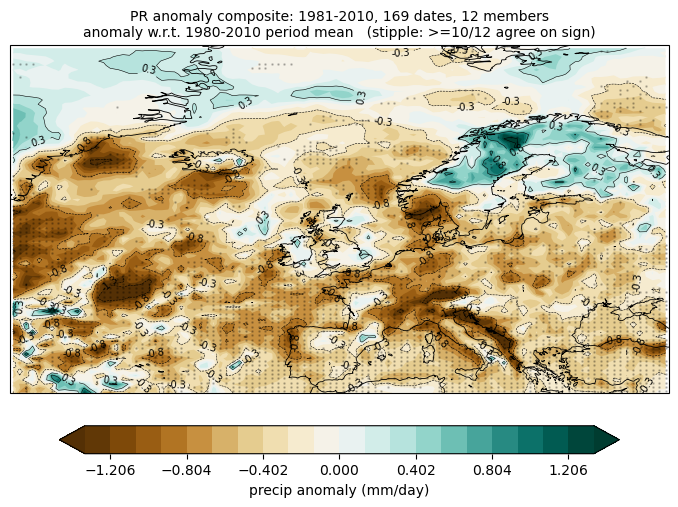

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import iris.plot as iplt

if SUBTRACT_CLIM:
    # diverging scale centred on zero for anomalies
    vmax = max(float(np.nanpercentile(np.abs(ens_mean_data), 99)), 0.5)
    levels = np.linspace(-vmax, vmax, 21)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
else:
    # sequential scale over the data range for a raw mean field
    lo = float(np.nanpercentile(ens_mean_data, 1))
    hi = float(np.nanpercentile(ens_mean_data, 99))
    levels = np.linspace(lo, hi, 21)
    norm = mcolors.Normalize(vmin=lo, vmax=hi)

fig = plt.figure(figsize=(8.5, 6.0))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

cf = iplt.contourf(ens_mean, levels=levels, cmap=FIELD_CMAP, norm=norm,
                   extend="both", axes=ax)
cs = iplt.contour(ens_mean, levels=levels[::4], colors="k", linewidths=0.4, axes=ax)
ax.clabel(cs, fmt=("%.1f" if VARIABLE == "pr" else "%.0f"), fontsize=7)

lons = ens_mean.coord("longitude").points
lats = ens_mean.coord("latitude").points
LON, LAT = np.meshgrid(lons, lats)
if SUBTRACT_CLIM:                               # sign agreement only means something for anomalies
    mask = n_agree >= AGREE_THRESHOLD
    ax.scatter(LON[mask], LAT[mask], s=0.8, color="k", alpha=0.2,
               transform=ccrs.PlateCarree(), zorder=4)

ax.coastlines(linewidth=0.6)
ax.set_extent([LON_RANGE[0], LON_RANGE[1], LAT_RANGE[0], LAT_RANGE[1]],
              crs=ccrs.PlateCarree())

if SUBTRACT_CLIM:
    _subtitle = (f"anomaly w.r.t. {CLIM_PERIOD[0]}-{CLIM_PERIOD[1]} "
                 f"{CLIM_KIND.replace('_', ' ')}   "
                 f"(stipple: >={AGREE_THRESHOLD}/{len(members_used)} agree on sign)")
    _kind = "anomaly composite"
else:
    _subtitle = "raw mean over the selected days (no climatology)"
    _kind = "mean composite"

ax.set_title(
    f"{VARIABLE.upper()} {_kind}: {ALL_LABELS[0][:4]}-{ALL_LABELS[-1][:4]}, "
    f"{len(ALL_LABELS)} dates, {len(members_used)} members\n" + _subtitle,
    fontsize=10)

cb = fig.colorbar(cf, ax=ax, orientation="horizontal", pad=0.07, shrink=0.85)
cb.set_label(FIELD_CBAR, fontsize=10)

fig.savefig(os.path.join(OUT_DIR, f"{VARIABLE}_{MODE_TAG}_ensemble_mean.png"),
            dpi=200, bbox_inches="tight")
plt.show()
